# Qwen Zero-Shot Quick Preview

Notebook ini untuk test hasil semantic label pada beberapa sampel saja (bukan seluruh dataset).
Notebook juga menampilkan gambar agar hasil inference mudah dicek visual.


In [1]:
from __future__ import annotations

import json
import random
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from PIL import Image
import torch
from tqdm.auto import tqdm
from transformers import AutoProcessor

try:
    from transformers import Qwen3VLForConditionalGeneration
except Exception:
    Qwen3VLForConditionalGeneration = None

try:
    from transformers import AutoModelForImageTextToText
except Exception:
    from transformers import AutoModelForVision2Seq as AutoModelForImageTextToText

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Jalankan notebook dari root repo /home/agung/riset')

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from emotion_reasoning.utils.image_ops import draw_red_box, load_rgb_image
from emotion_reasoning.utils.io import load_records, save_records


/home/agung/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
ANNOTATION_PATH = PROJECT_ROOT / 'notebook_outputs' / 'risetv1_qwen' / 'annotations' / 'caers_annotations_with_val.jsonl'
IMAGE_ROOT = PROJECT_ROOT / 'caer_dataset' / 'CAER-S'
MODEL_ID = 'Qwen/Qwen3-VL-4B-Instruct'
LOCAL_MODEL_DIR = PROJECT_ROOT / 'model_cache' / 'qwen3_vl_4b_instruct'
CACHE_DIR = PROJECT_ROOT / 'model_cache'

DEVICE = 'cuda:0'
MAX_NEW_TOKENS = 96
NUM_SAMPLES = 8
RANDOM_SEED = 42
SAMPLE_IDS = []  # isi list sample_id jika ingin sample tertentu
list_of_emotions = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# "Analyze the main person in the image. In a single, concise paragraph, describe their geometric facial features (e.g., 'flat lip line', 'narrowed eyes', 'lowered brow') and body posture. Then, describe the immediate environmental context. CRITICAL: Do NOT use any emotion-related words or adjectives (such as 'neutral', 'angry', 'relaxed', 'happy') to describe their expressions. Describe only the physical state."
PROMPT_WITH_BOX_TEMPLATE = (
    f"Given the following list of emotions: {list_of_emotions}, please explain in detail which emotions are more suitable for describing how the person feels based on the image context. Analyze the main person in the image. In a single, concise paragraph, describe their geometric facial features and body posture. Then, describe the immediate environmental context."
)
PROMPT_NO_BOX_TEMPLATE = PROMPT_WITH_BOX_TEMPLATE

if not torch.cuda.is_available():
    raise RuntimeError('CUDA tidak tersedia. Notebook ini disiapkan untuk inference GPU.')

if DEVICE != 'cuda' and DEVICE.startswith('cuda:'):
    gpu_idx = int(DEVICE.split(':', maxsplit=1)[1])
    if gpu_idx >= torch.cuda.device_count():
        raise RuntimeError(f'{DEVICE} tidak tersedia. GPU terdeteksi: {torch.cuda.device_count()}')

print('Config loaded')
print('Annotation:', ANNOTATION_PATH)
print('Image root:', IMAGE_ROOT)
print('Device:', DEVICE)


Config loaded
Annotation: /home/agung/riset/notebook_outputs/risetv1_qwen/annotations/caers_annotations_with_val.jsonl
Image root: /home/agung/riset/caer_dataset/CAER-S
Device: cuda:0


In [13]:
def local_model_ready(local_model_dir: Path) -> bool:
    if not local_model_dir.exists():
        return False
    if not (local_model_dir / 'model_manifest.json').exists():
        return False
    has_config = (local_model_dir / 'config.json').exists()
    has_weights = any(local_model_dir.glob('*.safetensors')) or any(local_model_dir.glob('pytorch_model*'))
    return has_config and has_weights


def resolve_dtype(device: str) -> torch.dtype:
    if not device.startswith('cuda'):
        return torch.float32
    if torch.cuda.is_bf16_supported():
        return torch.bfloat16
    return torch.float16


def load_qwen_components(source: str | Path, local_only: bool):
    processor = AutoProcessor.from_pretrained(
        source,
        trust_remote_code=True,
        cache_dir=str(CACHE_DIR),
        local_files_only=local_only,
    )

    model_kwargs = {
        'torch_dtype': resolve_dtype(DEVICE),
        'low_cpu_mem_usage': True,
        'cache_dir': str(CACHE_DIR),
        'local_files_only': local_only,
    }

    if Qwen3VLForConditionalGeneration is not None:
        model = Qwen3VLForConditionalGeneration.from_pretrained(source, **model_kwargs)
    else:
        model = AutoModelForImageTextToText.from_pretrained(source, **model_kwargs)

    model = model.to(DEVICE)
    model.eval()
    return processor, model


def write_model_manifest(local_model_dir: Path, model_id: str, source: str) -> None:
    payload = {
        'model_id': model_id,
        'source': source,
        'saved_at': datetime.now(timezone.utc).isoformat(),
    }
    (local_model_dir / 'model_manifest.json').write_text(
        json.dumps(payload, indent=2, ensure_ascii=False) + '\n',
        encoding='utf-8',
    )


def prepare_model(model_id: str, local_model_dir: Path):
    local_model_dir.mkdir(parents=True, exist_ok=True)

    if local_model_ready(local_model_dir):
        print('Model lokal sudah tersedia:', local_model_dir)
        processor, model = load_qwen_components(local_model_dir, local_only=True)
        return processor, model, 'local'

    try:
        processor, model = load_qwen_components(model_id, local_only=True)
        source = 'hf_cache'
        print('Model ditemukan di cache lokal Hugging Face untuk', model_id)
    except Exception:
        processor, model = load_qwen_components(model_id, local_only=False)
        source = 'downloaded'
        print('Model di-download dari Hugging Face:', model_id)

    print('Menyimpan salinan model ke:', local_model_dir)
    model.save_pretrained(local_model_dir, safe_serialization=True)
    processor.save_pretrained(local_model_dir)
    write_model_manifest(local_model_dir, model_id=model_id, source=source)
    return processor, model, source


def generate_caption(model, processor, image: Image.Image, prompt_text: str, max_new_tokens: int) -> str:
    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image},
                {'type': 'text', 'text': prompt_text},
            ],
        }
    ]

    if hasattr(processor, 'apply_chat_template'):
        inputs = processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors='pt',
        )
    else:
        fallback_prompt = f'USER: <image>\n{prompt_text}\nASSISTANT:'
        inputs = processor(images=image, text=fallback_prompt, return_tensors='pt')

    inputs = {
        key: value.to(model.device) if torch.is_tensor(value) else value
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    if 'input_ids' in inputs:
        output_ids = output_ids[:, inputs['input_ids'].shape[1] :]

    return processor.batch_decode(
        output_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()


In [14]:
# import gc
# gc.collect()
# torch.cuda.empty_cache()

In [4]:
processor, model, model_source = prepare_model(MODEL_ID, LOCAL_MODEL_DIR)
print('Model siap. Source:', model_source)


Model lokal sudah tersedia: /home/agung/riset/model_cache/qwen3_vl_4b_instruct


Loading weights: 100%|██████████| 713/713 [00:00<00:00, 12360.66it/s]


Model siap. Source: local


In [14]:
records = load_records(ANNOTATION_PATH)
print('Total records:', len(records))

labels_set: set[str] = set()
for row in records:
    value = row.get('labels', '')
    if isinstance(value, (list, tuple, set)):
        for item in value:
            text = str(item).strip()
            if text:
                labels_set.add(text)
    else:
        text = str(value).strip()
        if text:
            labels_set.add(text)

class_names = sorted(labels_set)
emotion_list_text = ', '.join(class_names)
prompt_with_box = PROMPT_WITH_BOX_TEMPLATE.format(emotion_list=emotion_list_text)
prompt_no_box = PROMPT_NO_BOX_TEMPLATE.format(emotion_list=emotion_list_text)

if SAMPLE_IDS:
    by_id = {str(r.get('sample_id', '')): r for r in records}
    selected_records = [by_id[sid] for sid in SAMPLE_IDS if sid in by_id]
else:
    random.seed(RANDOM_SEED)
    selected_records = random.sample(records, k=min(NUM_SAMPLES, len(records)))

print('Selected samples:', len(selected_records))
if not selected_records:
    raise ValueError('Tidak ada sampel terpilih. Cek SAMPLE_IDS atau NUM_SAMPLES.')


Total records: 69999
Selected samples: 8


preview-inference:   0%|          | 0/8 [00:00<?, ?it/s]

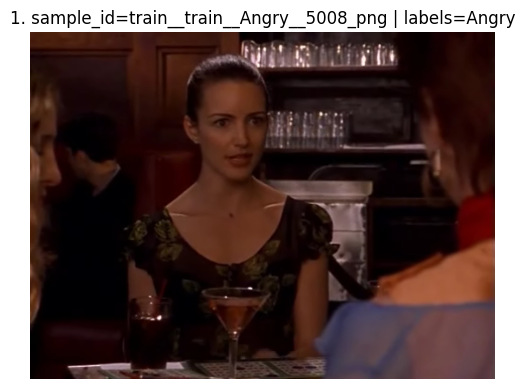

preview-inference:  12%|█▎        | 1/8 [00:03<00:22,  3.19s/it]

Semantic label (zero-shot):
The main person in the image exhibits a subtle expression of neutral-to-slightly-uneasy engagement, with no clear indicators of Angry, Disgust, Fear, Happy, Sad, or Surprise—her eyes are focused intently on the other person, lips slightly parted as if mid-conversation, and eyebrows relaxed, suggesting attentive listening rather than emotional intensity. Her geometric facial features are sharp and defined: high cheekbones, a straight nose, and a defined jawline create a
----------------------------------------------------------------------------------------------------


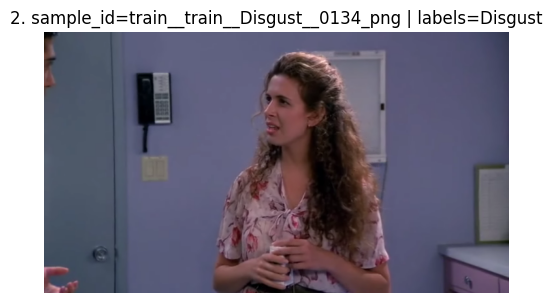

preview-inference:  25%|██▌       | 2/8 [00:06<00:19,  3.20s/it]

Semantic label (zero-shot):
The main person in the image exhibits a subtle expression of concern or mild frustration, leaning slightly toward the other individual while holding a cup, suggesting engagement in a serious or emotionally charged conversation; her slightly furrowed brow, parted lips, and direct gaze imply she is actively processing or responding to something, making “Angry” or “Sad” plausible, though not dominant, while “Disgust” or “Fear” are less likely given the lack of aversion or alarm
----------------------------------------------------------------------------------------------------


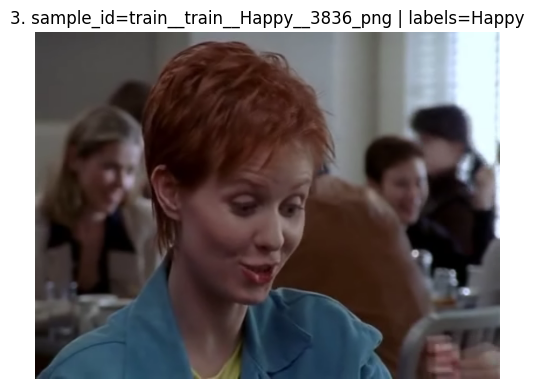

preview-inference:  38%|███▊      | 3/8 [00:09<00:15,  3.19s/it]

Semantic label (zero-shot):
The main person in the image—a woman with short, reddish-brown hair and a sharp, angular jawline—exhibits a subtle, engaged expression with slightly parted lips and a soft upward curve of the mouth, suggesting a gentle, amused curiosity rather than overt emotion. Her eyes are slightly narrowed and directed downward and to the side, indicating focused attention or mild intrigue. Her posture is relaxed yet attentive, leaning slightly forward as if listening or reacting to something off-camera.
----------------------------------------------------------------------------------------------------


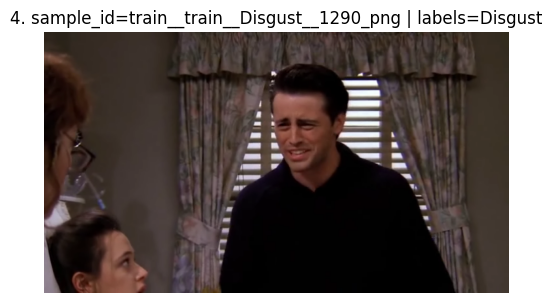

preview-inference:  50%|█████     | 4/8 [00:12<00:12,  3.20s/it]

Semantic label (zero-shot):
The central figure, a man in a dark sweater, exhibits a complex expression best described as a mixture of forced or ironic amusement and mild discomfort — leaning toward “Surprise” or “Sad” depending on interpretation, but not fitting cleanly into any single emotion. His facial features are geometrically defined: sharply arched eyebrows, a slightly downturned mouth with teeth slightly bared, and a tense jawline suggesting internal conflict or suppressed emotion. His body posture is upright but slightly h
----------------------------------------------------------------------------------------------------


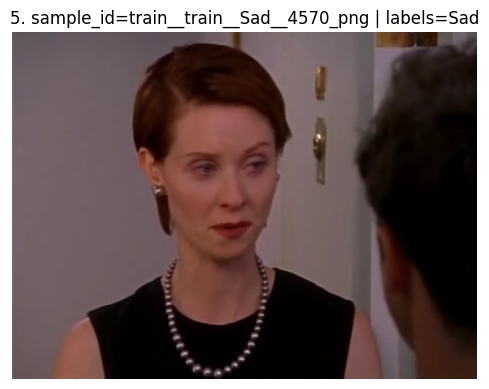

preview-inference:  62%|██████▎   | 5/8 [00:15<00:09,  3.18s/it]

Semantic label (zero-shot):
The woman’s facial expression conveys a subtle blend of Sadness and Disgust, with her slightly downturned lips, narrowed eyes, and furrowed brow suggesting emotional discomfort or disapproval rather than overt anger or fear. Her geometric facial features—sharp cheekbones, a straight nose, and a defined jawline—enhance the severity of her expression, while her upright, still posture and direct gaze toward the other person imply emotional intensity and focus. The environment is minimal
----------------------------------------------------------------------------------------------------


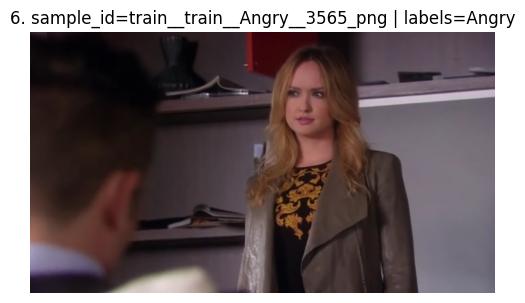

preview-inference:  75%|███████▌  | 6/8 [00:19<00:06,  3.19s/it]

Semantic label (zero-shot):
The main person in the image exhibits a subtle, composed expression best described as Neutral, with a faint hint of Sadness or Disgust, as her lips are slightly parted and her gaze is fixed intently on the other person, suggesting emotional reservation or mild disapproval rather than overt joy or alarm. Her facial features are geometrically defined—sharp cheekbones, a straight nose, and a defined jawline—enhancing the intensity of her stare. Her body posture is upright
----------------------------------------------------------------------------------------------------


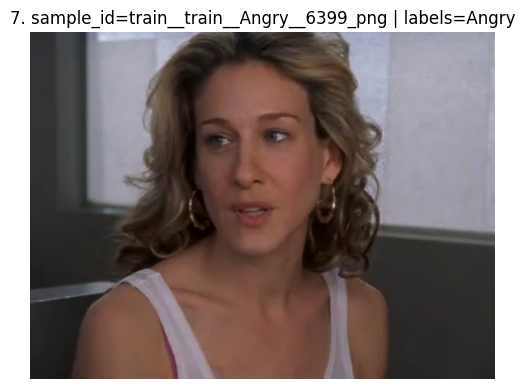

preview-inference:  88%|████████▊ | 7/8 [00:22<00:03,  3.19s/it]

Semantic label (zero-shot):
The person in the image exhibits a subtle expression of surprise or mild confusion, with her eyes slightly widened and her mouth slightly parted, suggesting she is reacting to unexpected information or an event; while her facial features—sharp cheekbones, defined jawline, and high cheekbones—contribute to a geometrically structured, angular visage, her posture is relaxed and slightly leaned forward, indicating engagement rather than tension. The environment is minimalistic and clinical, with a plain, light-colored
----------------------------------------------------------------------------------------------------


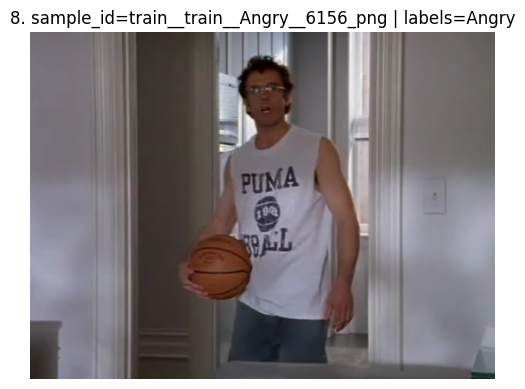

preview-inference: 100%|██████████| 8/8 [00:25<00:00,  3.19s/it]

Semantic label (zero-shot):
The person in the image exhibits a clear expression of surprise, characterized by wide, slightly bulging eyes, raised eyebrows, and an open mouth—suggesting sudden realization or shock—while their body posture is tense and slightly forward-leaning, as if reacting to an unexpected event. Their geometric facial features are defined by angular jawline and prominent cheekbones, framed by thick-rimmed glasses, and their posture conveys alertness rather than relaxation. The environmental context is a brightly lit
----------------------------------------------------------------------------------------------------
Selesai preview untuk 8 sampel


In [15]:
preview_results: list[dict[str, Any]] = []

for idx, row in enumerate(tqdm(selected_records, desc='preview-inference'), start=1):
    sid = str(row.get('sample_id', f'sample_{idx:06d}'))
    image_ref = Path(str(row['image_path']))
    image_path = image_ref if image_ref.is_absolute() else IMAGE_ROOT / image_ref

    image = load_rgb_image(image_path)
    bbox = row.get('bbox')

    if bbox not in (None, '', 'nan'):
        image_for_prompt = draw_red_box(image, bbox)
        prompt_text = prompt_with_box
    else:
        image_for_prompt = image
        prompt_text = prompt_no_box

    semantic_text = generate_caption(model, processor, image_for_prompt, prompt_text, MAX_NEW_TOKENS)

    labels_value = row.get('labels', '')
    if isinstance(labels_value, (list, tuple, set)):
        labels_value = ', '.join(str(x) for x in labels_value)

    preview_results.append({
        'sample_id': sid,
        'image_path': str(row.get('image_path', '')),
        'labels': labels_value,
        'semantic_pseudo_label': semantic_text,
    })

    plt.figure(figsize=(6, 6))
    plt.imshow(image_for_prompt)
    plt.axis('off')
    plt.title(f'{idx}. sample_id={sid} | labels={labels_value}')
    plt.show()

    print('Semantic label (zero-shot):')
    print(semantic_text)
    print('-' * 100)

print('Selesai preview untuk', len(preview_results), 'sampel')


In [ ]:
PREVIEW_OUTPUT_PATH = PROJECT_ROOT / 'notebook_outputs' / 'risetv1_qwen' / 'zero_shot_preview_results.jsonl'
save_records(PREVIEW_OUTPUT_PATH, preview_results)
print('Preview results saved:', PREVIEW_OUTPUT_PATH)
